# **Summary Note**

## ML Algorithms Used
- **Classifier**: XGBoost (XGB)
- **Regressor**: LASSO, XGBoost

## Input Features

| No. | Feature         | Description |
|-----|------------------|-------------|
| 1   | `size`           | Logarithm of market capitalization |
| 2   | `mom1m`          | 1-month momentum (current return) |
| 3   | `mom3m`          | 3-month momentum (excluding most recent month) |
| 4   | `mom6m`          | 6-month momentum (excluding most recent month) |
| 5   | `mom9m`          | 9-month momentum (excluding most recent month) |
| 6   | `mom12m`         | 12-month momentum (excluding most recent month) |
| 7   | `volatility`     | 12-month rolling standard deviation of returns |
| 8   | `amihud_illiq`   | Amihud illiquidity measure |
| 9   | `turnover`       | Daily turnover (volume ÷ shares outstanding) |
| 10  | `turnover_vol`   | 12-month rolling standard deviation of turnover |
| 11  | `ret_12m_ago`    | Return from 12 months ago |
| 12  | `ret_lag2`       | Return from 2 months ago |
| 13  | `ret_lag3`       | Return from 3 months ago |
| 14  | `ret_skew12m`    | 12-month rolling skewness of returns |
| 15  | `ret_mean12m`    | 12-month rolling mean of returns |
| 16  | `price_vs_avg`   | Price relative to its 12-month average |
| 17  | `drawdown_12m`   | Return minus 12-month rolling max return (drawdown) |


## Target Variables
- **Regression**: Normalized future return (`n_target_ret`)
- **Classification**: Return decile class (`target_cls`)


##  Main Findings

- The basic LASSO model showed unexpectedly solid performance.
- LASSO's performance was comparable to XGB in regression tasks, while also offering variable selection benefits.
- Our findings support the conclusion of the paper *"Empirical Asset Pricing via Machine Learning"*, which highlights the importance of size, momentum, and value features.
- Although portfolio returns initially appeared too strong to be believable, they were found to be consistent with real-world events, especially considering market shifts post-2020 (e.g., COVID-19 pandemic).

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import shuffle

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# --- Reproducibility & config ---
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# CRSP 월별 데이터 경로 (저작권 자료 — 로컬에 직접 준비, README 참고)
# 환경변수 CRSP_PATH 로 덮어쓸 수 있음
DATA_PATH = os.environ.get("CRSP_PATH", "./crspm.csv")

# **Data preprocessing**

#### **1. Exclusion of Stocks Ever Priced Below $5**
Instead of removing only low-price rows, we excluded any stock that was ever below $5 during the sample period to ensure reliable momentum and rolling feature calculations.

#### **2. Removal of Bottom 10% Market Cap (Monthly)**
The price filter was applied before market cap filtering to avoid distorting the percentile calculation.
This prevents illiquid or non-investable stocks from incorrectly remaining in the dataset.




In [ ]:
crsp = pd.read_csv(DATA_PATH)

crsp['prc'] = crsp['prc'].abs()
crsp['mcap'] = crsp['prc'] * crsp['shrout']
crsp['relvol'] = 0.1*crsp.vol/crsp.shrout 

low_price_permnos = crsp.loc[crsp['prc'] <= 5, 'permno'].unique()

crsp = crsp[~crsp['permno'].isin(low_price_permnos)].copy()



crsp['yyyymm'] = pd.to_datetime(crsp['date']).dt.to_period('M')
crsp = (
    crsp.groupby('yyyymm')
    .apply(lambda x: x[x['mcap'] >= x['mcap'].quantile(0.1)])
    .reset_index(drop=True)
)

crsp = crsp.drop(columns=['yyyymm'])


## **Feature Processing**

In addition to the basic input features used in class, we added other features to improve the model’s performance.  


In [56]:
import numpy as np
import pandas as pd


crsp['prc'] = crsp['prc'].abs()
crsp['mcap'] = crsp['prc'] * crsp['shrout']
crsp['logret'] = np.log(1 + crsp['ret'])

crsp['target_ret'] = crsp.groupby('permno')['ret'].shift(-1)
crsp = crsp.dropna(subset=['target_ret'])

crsp['n_target_ret'] = crsp.groupby('date')['target_ret'].transform(lambda x: (x - x.mean()) / x.std())
crsp['target_cls'] = crsp.groupby('date')['target_ret'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))

crsp['size'] = np.log(crsp['mcap'])
crsp['mom1m'] = crsp['ret']
crsp['mom3m'] = crsp.groupby('permno')['logret'].transform(lambda x: np.exp(x.shift(1).rolling(2).sum()) - 1)
crsp['mom6m'] = crsp.groupby('permno')['logret'].transform(lambda x: np.exp(x.shift(1).rolling(5).sum()) - 1)
crsp['mom9m'] = crsp.groupby('permno')['logret'].transform(lambda x: np.exp(x.shift(1).rolling(8).sum()) - 1)
crsp['mom12m'] = crsp.groupby('permno')['logret'].transform(lambda x: np.exp(x.shift(1).rolling(11).sum()) - 1)
crsp['volatility'] = crsp.groupby('permno')['ret'].transform(lambda x: x.rolling(12, min_periods=6).std())

dollar_volume = crsp['prc'] * crsp['vol']
crsp['amihud_illiq'] = np.log(1 + (crsp['ret'].abs() / (dollar_volume + 1e-8)))
crsp['turnover'] = crsp['vol'] / crsp['shrout']
crsp['turnover_vol'] = crsp.groupby('permno')['turnover'].transform(lambda x: x.rolling(12, min_periods=6).std())

crsp['ret_12m_ago'] = crsp.groupby('permno')['ret'].shift(12)
crsp['ret_lag2'] = crsp.groupby('permno')['ret'].shift(2)
crsp['ret_lag3'] = crsp.groupby('permno')['ret'].shift(3)

crsp['ret_skew12m'] = crsp.groupby('permno')['ret'].transform(lambda x: x.rolling(12, min_periods=6).skew())
crsp['ret_mean12m'] = crsp.groupby('permno')['ret'].transform(lambda x: x.rolling(12, min_periods=6).mean())

crsp['avg_prc_12m'] = crsp.groupby('permno')['prc'].transform(lambda x: x.rolling(12, min_periods=6).mean())
crsp['price_vs_avg'] = crsp['prc'] / crsp['avg_prc_12m']

crsp['rolling_max_ret'] = crsp.groupby('permno')['ret'].transform(lambda x: x.rolling(12, min_periods=6).max())
crsp['drawdown_12m'] = crsp['ret'] - crsp['rolling_max_ret']

x_cols =[
    'size', 'mom1m', 'mom3m', 'mom6m', 'mom9m', 'mom12m',
    'volatility', 'amihud_illiq', 'turnover', 'turnover_vol',
    'ret_12m_ago', 'ret_lag2', 'ret_lag3',
    'ret_skew12m', 'ret_mean12m',
    'price_vs_avg', 'drawdown_12m'
]


c:\Users\Hoseung\.conda\envs\env_bitcoin\lib\site-packages\pandas\core\window\rolling.py:611: RuntimeWarning: All-NaN slice encountered
  return func(x, start, end, min_periods, *numba_args)


## **Function Definitions**

In [ ]:
def portfolio_return(df, ret_col='target_ret', wgt_col=None):
    """
    Calculates portfolio return using equal or value weights.
    """
    if df.empty:
        return 0
    if wgt_col is None: #
        return df[ret_col].mean()
    else: 
        wgt = df[wgt_col] / df[wgt_col].sum()
        return np.dot(df[ret_col], wgt)

def backtest_strategy(model, test_df, model_type):
    """
    Runs a backtest by creating long/short portfolios using model predictions.
    """
    r_h_ew, r_l_ew, r_h_vw, r_l_vw = {}, {}, {}, {}
    for m, test_m in test_df.groupby('date'):
        x_test_m = test_m[x_cols]
        if model_type == 'classifier':
            y_pred = model.predict(x_test_m)
            long_stocks = test_m.iloc[y_pred == 9]
            short_stocks = test_m.iloc[y_pred == 0]
        elif model_type == 'regressor':
            y_pred = model.predict(x_test_m)
            test_m['pred_score'] = y_pred
            q_10 = test_m['pred_score'].quantile(0.9)
            q_1 = test_m['pred_score'].quantile(0.1)
            long_stocks = test_m[test_m['pred_score'] >= q_10]
            short_stocks = test_m[test_m['pred_score'] <= q_1]

        r_h_ew[m] = portfolio_return(long_stocks)
        r_l_ew[m] = portfolio_return(short_stocks)
        r_h_vw[m] = portfolio_return(long_stocks, wgt_col='mcap')
        r_l_vw[m] = portfolio_return(short_stocks, wgt_col='mcap')

    pf_ret_ew = pd.DataFrame({'H': r_h_ew, 'L': r_l_ew})
    pf_ret_vw = pd.DataFrame({'H': r_h_vw, 'L': r_l_vw})
    pf_ret_ew['H-L'] = pf_ret_ew['H'] - pf_ret_ew['L']
    pf_ret_vw['H-L'] = pf_ret_vw['H'] - pf_ret_vw['L']
    return pf_ret_ew, pf_ret_vw

def evaluate(r_p):
    """
    Calculates key performance metrics from a return series.
    """
    if r_p.empty or r_p.std() == 0:
        return [0, 0, 0, 0, 0]
    cum_ret = (1 + r_p).cumprod() - 1
    mean_ret = 12 * r_p.mean()
    std_ret = np.sqrt(12) * r_p.std()
    sharpe = mean_ret / std_ret
    mdd = ( (1 + cum_ret).div((1 + cum_ret).cummax()) - 1 ).min()
    return [cum_ret.iloc[-1], mean_ret, std_ret, sharpe, mdd]

def analyze_and_plot(pf_ret_ew, pf_ret_vw, model_name):
    """
    Prints performance summary and plots cumulative returns.
    """
    result = pd.DataFrame(index=['Cumulative', 'Annualized Mean', 'Annualized Std', 'Sharpe', 'Max Drawdown'])
    result[f'{model_name}_EW_H'] = evaluate(pf_ret_ew['H'])
    result[f'{model_name}_EW_L'] = evaluate(pf_ret_ew['L'])
    result[f'{model_name}_EW_HL'] = evaluate(pf_ret_ew['H'] - pf_ret_ew['L'])
    result[f'{model_name}_VW_H'] = evaluate(pf_ret_vw['H'])
    result[f'{model_name}_VW_L'] = evaluate(pf_ret_vw['L'])
    result[f'{model_name}_VW_HL'] = evaluate(pf_ret_vw['H'] - pf_ret_vw['L'])

    print(f"\n[{model_name}] 포트폴리오 성과 요약:")
    ordered_cols = [
        f'{model_name}_EW_H', f'{model_name}_EW_L', f'{model_name}_EW_HL',
        f'{model_name}_VW_H', f'{model_name}_VW_L', f'{model_name}_VW_HL'
    ]
    display(result[ordered_cols].round(3))

    np.log(1 + pf_ret_ew).cumsum().plot(title=f'{model_name} Equal-Weighted Portfolio Cumulative Return', figsize=(10, 5))
    plt.ylabel('Cumulative Return (log scale)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    np.log(1 + pf_ret_vw).cumsum().plot(title=f'{model_name} Value-Weighted Portfolio Cumulative Return', figsize=(10, 5))
    plt.ylabel('Cumulative Return (log scale)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()   

def summarize_and_print_results(model_name, results):
    """
    Summarizes performance metrics across multiple runs.
    """
    print(f"\n[{model_name}] 훈련 10회 결과 요약:")
    keys = results[0].keys()
    stats = {}

    for key in keys:
        mat = np.array([r[key] for r in results])
        merged = mat.flatten()

        stats[key] = {
            'min': merged.min(),
            'max': merged.max(),
            'avg': merged.mean(),
            'vol': merged.std()
        }

    print("\n▶ Cumulative Return Summary")
    print(f"{'Key':<10} {'MIN':>10} {'MAX':>10} {'AVG':>10} {'VOL':>10}")
    print("-" * 50)
    for key, val in stats.items():
        print(f"{key:<10} {val['min']:10.6f} {val['max']:10.6f} {val['avg']:10.6f} {val['vol']:10.6f}")



# **LASSO Regressor**

Fitting 3 folds for each of 7 candidates, totalling 21 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=2000))]),
             n_jobs=-1,
             param_grid={'lasso__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01,
                                          0.05, 0.1]},
             scoring='neg_mean_squared_error', verbose=1)


[Lasso_Regressor] 포트폴리오 성과 요약:


,Lasso_Regressor_EW_H,Lasso_Regressor_EW_L,Lasso_Regressor_EW_HL,Lasso_Regressor_VW_H,Lasso_Regressor_VW_L,Lasso_Regressor_VW_HL
Cumulative,61.817,4.176,12.742,19.419,4.676,3.179
Annualized Mean,0.333,0.127,0.205,0.260,0.135,0.125
Annualized Std,0.258,0.132,0.181,0.288,0.136,0.211
Sharpe,1.291,0.963,1.133,0.902,0.990,0.592
Max Drawdown,-0.323,-0.175,-0.324,-0.501,-0.216,-0.511


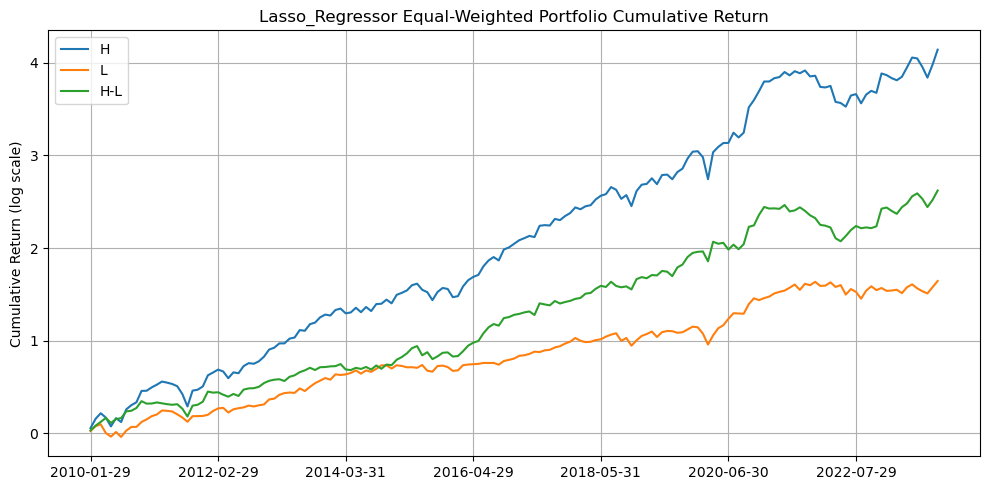

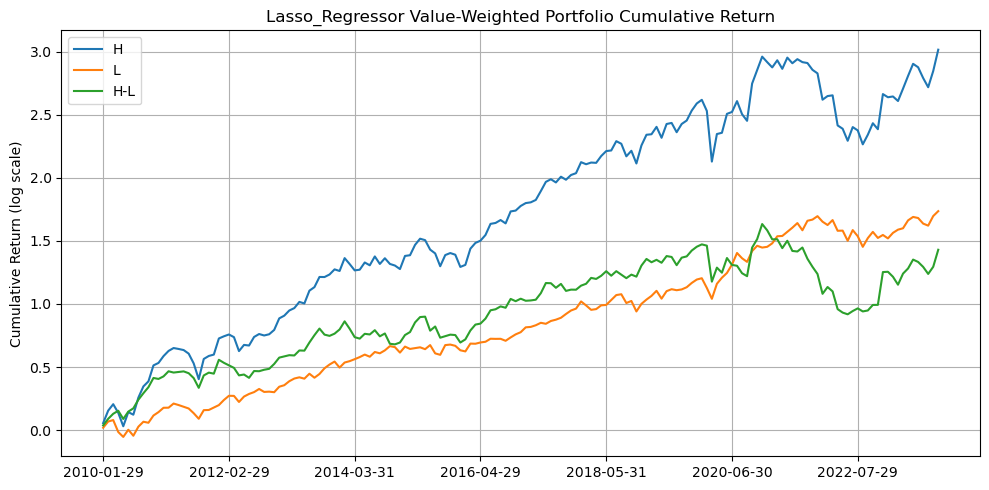

In [169]:
train = crsp[crsp.date < '2010-01-01'].copy()
test = crsp[crsp.date >= '2010-01-01'].copy()

train.dropna(subset=x_cols + ['target_cls', 'n_target_ret'], inplace=True)
test.dropna(subset=x_cols, inplace=True)

x_train = train[x_cols]
y_train = train['n_target_ret']

pipeline_lasso = make_pipeline(StandardScaler(), Lasso(max_iter=2000))
param_grid_lasso = {'lasso__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]}

grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_lasso.fit(x_train, y_train)
lasso_model = grid_lasso.best_estimator_

pf_ret_lasso_ew, pf_ret_lasso_vw = backtest_strategy(lasso_model, test, 'regressor')

analyze_and_plot(pf_ret_lasso_ew, pf_ret_lasso_vw, 'Lasso_Regressor')


In [173]:
lasso_coef = lasso_model.named_steps['lasso'].coef_

lasso_coef_df = pd.DataFrame({
    'Feature': x_cols,
    'Coefficient': lasso_coef
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n[Selected Features and Coefficients from Lasso Regression]")

print(lasso_coef_df.to_string(index=False))


[Selected Features and Coefficients from Lasso Regression]
     Feature  Coefficient
 ret_mean12m    -0.068849
      mom12m     0.061765
        size    -0.037985
  volatility     0.021785
 ret_12m_ago    -0.018548
       mom1m    -0.017875
       mom3m    -0.013403
       mom9m     0.012253
    ret_lag3    -0.010737
    ret_lag2     0.007016
turnover_vol     0.006302
price_vs_avg    -0.005562
drawdown_12m    -0.003856
    turnover     0.002701
amihud_illiq    -0.001604
 ret_skew12m    -0.000000
       mom6m    -0.000000


Lasso regression showed steady and solid performance, with the H–L (high-minus-low) portfolio achieving good cumulative returns during the test period.  
Even though Lasso is a simpler model compared to something like XGBoost, it still performed similarly well, showing that regularized linear models can work effectively in practice.

What’s interesting is that Lasso kept features like momentum (e.g., mom12m, mom9m), size, and volatility — which are commonly known to be important in asset pricing.  
This matches what I saw in the paper *Empirical Asset Pricing via Machine Learning*, which I reviewed earlier, where momentum, size, and value were also found to be key factors.

Overall, these results suggest that even a simple linear model like Lasso can capture meaningful patterns in return prediction, as long as feature selection is done well.

Lasso was not tuned or repeated 10 times like other models.(But I did XGB Regression) 
Since it's a deterministic method, it always gives the same output for the same input, so running it multiple times is unnecessary.


# **XGBoost Regressor**

In [ ]:
train = crsp[crsp.date < '2010-01-01'].copy()
test = crsp[crsp.date >= '2010-01-01'].copy()

train.dropna(subset=x_cols + ['target_cls', 'n_target_ret'], inplace=True)
test.dropna(subset=x_cols, inplace=True)

x_train = train[x_cols]
y_train = train['n_target_ret']


param_grid_xgb = {'learning_rate': [0.1, 0.05], 'n_estimators': [100], 'max_depth': [3, 5]}

grid_xgb = GridSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=SEED),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(x_train, y_train)

xgb_model = grid_xgb.best_estimator_
pf_ret_xgb_ew, pf_ret_xgb_vw = backtest_strategy(xgb_model, test, 'regressor')
analyze_and_plot(pf_ret_xgb_ew, pf_ret_xgb_vw, 'XGBRegressor')

results = []

for seed in range(10):
    param_grid_xgb = {'learning_rate': [0.1, 0.05], 'n_estimators': [100], 'max_depth': [3, 5]}
    
    x_train, y_train = shuffle(x_train, y_train, random_state=seed)
    
    grid_xgb = GridSearchCV(
        XGBRegressor(objective='reg:squarederror', random_state=SEED),
        param_grid=param_grid_xgb,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=24,
        verbose=0
    )
    _ = grid_xgb.fit(x_train, y_train)

    xgb_model = grid_xgb.best_estimator_
    pf_ret_ew, pf_ret_vw = backtest_strategy(xgb_model, test, 'regressor')
    row = {
        'EW_H': evaluate(pf_ret_ew['H']),
        'EW_L': evaluate(pf_ret_ew['L']),
        'EW_HL': evaluate(pf_ret_ew['H'] - pf_ret_ew['L']),
        'VW_H': evaluate(pf_ret_vw['H']),
        'VW_L': evaluate(pf_ret_vw['L']),
        'VW_HL': evaluate(pf_ret_vw['H'] - pf_ret_vw['L']),
    }
    results.append(row)
summarize_and_print_results("XGB", results)

# **XGBoost Classifier**

In [ ]:
train = crsp[crsp.date < '2010-01-01'].copy()
test = crsp[crsp.date >= '2010-01-01'].copy()

train.dropna(subset=x_cols + ['target_cls', 'n_target_ret'], inplace=True)
test.dropna(subset=x_cols + ['target_cls'], inplace=True)

x_train = train[x_cols]
y_train = train['target_cls']  

param_grid_xgb = {
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        num_class=10,
        eval_metric='mlogloss',
        random_state=SEED
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(x_train, y_train)

xgb_model = grid_xgb.best_estimator_

pf_ret_xgb_ew, pf_ret_xgb_vw = backtest_strategy(xgb_model, test, 'classifier')
analyze_and_plot(pf_ret_xgb_ew, pf_ret_xgb_vw, 'XGBClassifier')


results = []

for seed in range(10):

    param_grid_xgb = {
        'learning_rate': [0.1, 0.05],
        'n_estimators': [100],
        'max_depth': [3, 5]
    }

    x_train_shuf, y_train_shuf = shuffle(x_train, y_train, random_state=seed)

    grid_xgb = GridSearchCV(
        XGBClassifier(objective='multi:softprob', random_state=SEED),
        param_grid=param_grid_xgb,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    _ = grid_xgb.fit(x_train_shuf, y_train_shuf)
    xgb_model = grid_xgb.best_estimator_

    pf_ret_ew, pf_ret_vw = backtest_strategy(xgb_model, test, 'classifier')

    row = {
        'EW_H': evaluate(pf_ret_ew['H']),
        'EW_L': evaluate(pf_ret_ew['L']),
        'EW_HL': evaluate(pf_ret_ew['H'] - pf_ret_ew['L']),
        'VW_H': evaluate(pf_ret_vw['H']),
        'VW_L': evaluate(pf_ret_vw['L']),
        'VW_HL': evaluate(pf_ret_vw['H'] - pf_ret_vw['L']),
    }
    results.append(row)

summarize_and_print_results("XGB", results)
